# Sensor placement POC — does *where* we measure change *what* dependence we detect?

Placement is a column selection over `pressures` / `flows`, so all strategies are
scored on one simulated world. Nothing upstream changes and nothing is re-simulated.

**Ground rules.** A strategy sees network topology and each client's own residual
series. `gt_boundaries` is used only to score. Every district gets the same channel
template (2 pressure + 3 flow, same order) and no physical element is metered by two
districts — otherwise their coupling is trivially perfect.

**Run this on `coupling.variant: baseline`.** Under `partial`, a closed boundary pipe
is simultaneously a topological fact a strategy can see and the evaluation label, so
a topology-driven strategy leaks. Cell 2 guards this.

In [4]:
import sys, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd().resolve()
PROJ = next((p for p in [HERE, *HERE.parents] if (p / "pyproject.toml").exists()), HERE)

for p in (PROJ / "src", PROJ / "notebooks", PROJ, HERE):   # fedwater, then engine
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import fedwater                    # fails loudly here if src/ is wrong
import placement_poc as P

from kedro.framework.session import KedroSession
from kedro.framework.startup import bootstrap_project

bootstrap_project(PROJ)
with KedroSession.create(project_path=PROJ) as session:
    ctx = session.load_context()
catalog, params = ctx.catalog, ctx.params

wn         = catalog.load("wn_variant")
districts  = catalog.load("districts")
pressures  = catalog.load("pressures")
flows      = catalog.load("flows")
gt_bounds  = catalog.load("gt_boundaries")

STEPS_DAY = int(24 / params["time"]["resolution_h"])
T         = len(pressures)
SEED      = 0
pd.set_option("display.width", 140)
print(f"root={PROJ} | fedwater={pathlib.Path(fedwater.__file__).parent}")
print(f"{T} steps | {len(wn.junction_name_list)} junctions | "
      f"{len(wn.pipe_name_list)} pipes | coupling={params['coupling']['variant']}")

[09/02/26 10:27:08] INFO     Using                                                                  ]8;id=549660;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=71965;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framework\project\__init__.py#302\302]8;;\
                             'c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\framewo                
                             rk\project\rich_logging.yml' as logging configuration.                                

[09/02/26 10:28:11] INFO     No typed parameter requirements found, returning original   ]8;id=938569;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=462102;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

[09/02/26 10:28:13] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=902230;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=129356;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[09/02/26 10:28:31] INFO     Loading data from wn_variant (PickleDataset)...                   ]8;id=886834;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=422695;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

[09/02/26 10:28:32] INFO     Loading data from districts (YAMLDataset)...                      ]8;id=341055;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=593429;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

                    INFO     Loading data from pressures (ParquetDataset)...                   ]8;id=186584;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=388094;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

[09/02/26 10:29:12] INFO     Loading data from flows (ParquetDataset)...                       ]8;id=710592;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=742084;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

[09/02/26 10:29:14] INFO     Loading data from gt_boundaries (CSVDataset)...                   ]8;id=490067;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=16958;file://c:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

root=C:\Users\arthu\USPy\10_Mestrado\fedWater | fedwater=C:\Users\arthu\USPy\10_Mestrado\fedWater\src\fedwater
17280 steps | 113 junctions | 164 pipes | coupling=baseline


## SC-0 — world guard and candidate inventory

In [5]:
assert params["coupling"]["variant"] == "baseline", (
    "Run the POC on `baseline`. Under `partial`, closed boundaries are both a "
    "topological input and the evaluation label.")

cands = P.candidate_table(wn, districts)
display(cands.groupby(["district", "kind", "scope"]).size().unstack(fill_value=0))

scope                boundary  internal  node
district   kind                              
District_A flow             2        16     0
           pressure         0         0    12
District_B flow             2        43     0
           pressure         0         0    29
District_C flow             4        22     0
           pressure         0         0    18
District_D flow             6        28     0
           pressure         0         0    24
District_E flow             4        45     0
           pressure         0         0    30

## SC-1 — is pressure actually uninformative across clients?

`within` / `across` are mean |corr| between month-aware residuals of two elements in
the same / different districts. A kind whose `discriminative_gap` is ~0 carries no
district-specific information: every client is watching the same signal, and no
placement of it can help.

In [6]:
sc1 = P.sc_pressure_vs_flow(pressures, flows, cands, STEPS_DAY)
display(sc1)

,kind,n_elements,within_abs_corr,across_abs_corr,discriminative_gap,resid_std_cv
0,pressure,113,0.999942,0.996618,0.003323,0.064025
1,flow,163,0.402193,0.168480,0.233713,0.778128


## SC-2 — do the estimators recover a known answer *at this sample size*?

AR(1) with `a -> b` at lag 1, an independent series, and a mediated chain
`a -> mid -> far`. Run at the study's own `n`, so the verdict is about this design
rather than about the `n = 3000` used in the unit tests.

In [7]:
sc2 = P.sc_estimators_known_truth(T, seed=SEED)
display(sc2)
if not sc2["passed"].all():
    print("FAILED:", list(sc2.loc[~sc2.passed, "check"]),
          "-- fix before reading any placement result.")

,check,value,passed
0,coupled_detected,0.010000,True
1,independent_not_detected,0.910000,True
2,granger_direction,1261.037575,True
3,lead_lag_is_1,1.000000,True
4,mediated_path_suppressed,0.002952,True
5,rv_separates,0.999869,True


## Topology features, and SC-3: does the structural proxy predict the physics?

`carry` is source→junction edge betweenness, standing in for "share of network demand
transiting this element". If it does not correlate with simulated mean |flow|, the
boundary strategy is optimizing a fiction and should be dropped.

In [8]:
feats, dist = P.topology_features(wn, districts, cands)
stats = P.residual_stats(pressures, flows, cands, STEPS_DAY)
display(P.sc_topology_vs_physics(feats, cands, flows, STEPS_DAY, pressures))
display(feats.join(cands[["district", "kind", "scope"]])
        .groupby(["kind", "scope"])[["d_boundary", "carry"]].median())

,check,value,passed
0,carry_vs_mean_abs_flow,0.494763,True


d_boundary     carry
kind     scope                         
flow     boundary         0.0  0.000466
         internal      1338.0  0.000078
pressure node          1567.0  0.000233

## Strategies

| name | gain | redundancy weight |
|---|---|---|
| `manual` | current `parameters.yml` placement | — |
| `random` | uniform | 0 |
| `variance` | residual std (redundancy-blind; expected to cluster) | 0 |
| `spread` | none — pure max-min graph separation | 1.0 |
| `boundary` | `0.5·carry − 0.5·d_boundary` | 0.5 |

`spread` is the Khorshidi Transinformation-Entropy idea with a deterministic
topological surrogate in place of an estimated entropy. `boundary` adds the
coupling-observability term. Neither touches `gt_boundaries`.

In [9]:
placements = P.strategies(cands, feats, stats, dist, params, seed=SEED)
sc4 = P.sc_inventory(wn, districts, cands, placements)
assert sc4["passed"].all(), sc4[~sc4.passed]
display(sc4[sc4.check.str.contains("pool|partition")])

display(pd.DataFrame([{"strategy": n, "district": d,
                       "pressure": ",".join(v["pressure"]),
                       "flow": ",".join(v["flow"])}
                      for n, pl in placements.items() for d, v in pl.items()])
        .pivot(index="district", columns="strategy", values="flow"))

,check,value,passed
0,junctions_partitioned,0,True
1,min_pool_pressure,12,True
2,min_pool_flow,18,True


strategy,boundary,manual,random,spread,variance
district,,,,,
District_A,"104,103,176","102,100,85","174,177,178","175,179,104","136,103,102"
District_B,"136,134,133","157,135,165","151,139,141","159,136,170","129,131,134"
District_C,"97,95,129","110,119,91","91,95,118","113,105,182","104,97,119"
District_D,"96,44,69","38,96,69","67,46,4","140,97,67","94,96,45"
District_E,"67,181,65","59,11,19","61,53,10","14,78,21","145,67,6"


## Evaluation

Per district-pair statistic on month-aware residuals. `pearson` / `partial_corr` /
`granger_max` run on the district-mean signal; `rv` / `partial_rv` run on the district's
**sensor matrix**, which is the part that actually responds to placement — averaging a
district's sensors into one series is what erases the effect.

AUROC is against "pair shares an open boundary pipe", over 10 pairs. With 10 pairs this
is a direction, not a result: read the `margin` column alongside it.

In [10]:
N_SUR = 99
rows, detail = [], {}
for name, pl in placements.items():
    scores, rec = P.evaluate(pressures, flows, pl, districts, gt_bounds,
                             STEPS_DAY, noise=None, seed=SEED, n_sur=N_SUR)
    detail[name] = scores
    rec.insert(0, "strategy", name)
    rows.append(rec)
recovery = pd.concat(rows, ignore_index=True)

display(recovery.pivot_table(index=["kind", "method"], columns="strategy",
                             values="auroc").round(3))
display(recovery.pivot_table(index=["kind", "method"], columns="strategy",
                             values="margin").round(4))

strategy               boundary  manual  random  spread  variance
kind     method                                                  
flow     granger_max       0.68    0.68    0.52    0.72      0.76
         partial_corr      0.72    0.60    0.72    0.68      0.96
         partial_rv        1.00    0.60    0.68    0.80      0.96
         pearson           0.68    0.68    0.56    0.36      0.92
         rv                0.68    0.56    0.64    0.64      0.76
pressure granger_max       0.36    0.32    0.28    0.36      0.24
         partial_corr      0.88    0.88    1.00    0.88      1.00
         partial_rv        0.96    0.72    0.80    0.92      1.00
         pearson           0.96    0.96    0.96    0.88      0.92
         rv                0.96    0.96    0.96    0.88      0.92

strategy               boundary   manual   random   spread  variance
kind     method                                                     
flow     granger_max     0.4769  22.5661  48.7599  29.1912   18.1238
         partial_corr    0.2136   0.1395   0.2192   0.0533    0.3022
         partial_rv      0.3935   0.0315   0.1053   0.2256    0.2635
         pearson         0.0744   0.0932   0.1681  -0.1300    0.3086
         rv              0.0963   0.0737   0.1700   0.0560    0.1648
pressure granger_max    -7.6366 -13.5960 -16.6375 -12.0468  -24.5955
         partial_corr    0.3923   0.3673   0.4240   0.3502    0.4446
         partial_rv      0.3903   0.2781   0.2476   0.3888    0.3156
         pearson         0.0023   0.0032   0.0033   0.0032    0.0036
         rv              0.0046   0.0065   0.0067   0.0064    0.0072

### Robustness: with measurement noise

`sensing.add_measurement_noise` keys its RNG on `hash(sensor)`, which Python salts per
process, so this table is **not** reproducible across kernel restarts. Treat it as a
robustness check on the ordering above, not as a number to quote.

In [11]:
noisy = []
for name, pl in placements.items():
    _, rec = P.evaluate(pressures, flows, pl, districts, gt_bounds, STEPS_DAY,
                        noise=params["noise"], seed=42, n_sur=N_SUR)
    rec.insert(0, "strategy", name)
    noisy.append(rec)
noisy = pd.concat(noisy, ignore_index=True)
display(noisy.pivot_table(index=["kind", "method"], columns="strategy",
                          values="auroc").round(3))

strategy               boundary  manual  random  spread  variance
kind     method                                                  
flow     granger_max       0.84    0.64    0.56    0.36      0.72
         partial_corr      0.84    0.76    0.68    0.64      1.00
         partial_rv        1.00    0.68    0.64    0.72      1.00
         pearson           0.68    0.68    0.56    0.36      0.92
         rv                0.68    0.60    0.64    0.60      0.80
pressure granger_max       0.44    0.52    0.40    0.44      0.40
         partial_corr      0.52    0.48    0.52    0.52      0.56
         partial_rv        0.52    0.48    0.52    0.52      0.48
         pearson           0.44    0.44    0.48    0.44      0.44
         rv                0.44    0.44    0.48    0.44      0.44

## SC-5 / SC-6 — estimator stability and null calibration

`sc_sample_size` recomputes the statistic on the first and last `n` steps. The spread
between the two columns at a given `n` is the honest error bar, and the reason selection
uses the full horizon rather than an 84-step window.

`sc_null_calibration` shifts one district by half the horizon: a calibrated statistic
must collapse toward its null.

In [12]:
best = "boundary"
ss = P.build_series(pressures, flows, placements[best])
mats, sigs = P.district_data(ss, STEPS_DAY)
ds = sorted(districts["districts"])

display(P.sc_sample_size(mats, sigs, [84, 336, 2016, 8640, T],
                         (ds[0], ds[1]), "flow", n_sur=N_SUR, seed=SEED))
display(P.sc_null_calibration(mats, "flow", n_sur=N_SUR, seed=SEED))

p_value        pearson              rv        
half    first second   first  second   first  second
n                                                   
84       0.06   0.01  0.4608  0.8501  0.6001  0.8717
336      0.01   0.01  0.7428  0.8581  0.7967  0.9009
2016     0.01   0.01  0.6909  0.7420  0.7200  0.7526
8640     0.01   0.01  0.7621  0.7684  0.7696  0.7469
17280    0.01   0.01  0.7650  0.7650  0.7582  0.7582

,check,value,p_value,passed
0,observed_rv,0.758155,0.01,True
1,shifted_rv,0.000039,0.94,True


## Headline

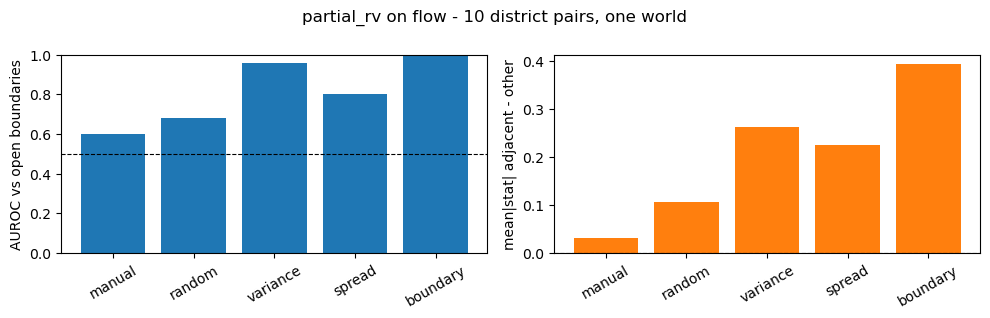

In [13]:
KIND, METHOD = "flow", "partial_rv"
sub = recovery[(recovery.kind == KIND) & (recovery.method == METHOD)] \
    .set_index("strategy").loc[list(placements)]

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].bar(sub.index, sub["auroc"]); ax[0].axhline(0.5, ls="--", c="k", lw=0.8)
ax[0].set_ylabel("AUROC vs open boundaries"); ax[0].set_ylim(0, 1)
ax[1].bar(sub.index, sub["margin"], color="tab:orange")
ax[1].axhline(0, ls="--", c="k", lw=0.8)
ax[1].set_ylabel("mean|stat| adjacent - other")
for a in ax:
    a.tick_params(axis="x", rotation=30)
fig.suptitle(f"{METHOD} on {KIND} - 10 district pairs, one world")
fig.tight_layout(); plt.show()

## Reading this

- **If the strategies are indistinguishable**, coupling observability is topology-limited,
  not sensor-limited on Graeme — a real finding, and the cue to move to a larger or
  multi-source network rather than a better optimizer.
- **If `boundary` beats `manual`**, the next step is promoting placement to a sweep axis
  in `experiments.yml` and re-running across worlds and coupling variants — 10 pairs in
  one world is a direction, not a result.
- **If SC-1 shows no discriminative gap on pressure**, drop pressure candidates and
  spend the whole template on flow, and revisit `dependence_oracle.topology_features`,
  which currently computes hydraulic distance between *pressure* sensor nodes.

Not in scope here, deliberately: NSGA-II, MCDM weighting scenarios, leak simulation,
multi-world replication.